In [8]:
from pathlib import Path

from prismadv.data_models import Constraints
from workflow_prismadv.utils.results_analysis import collect_results
from workflow_prismadv.utils.results_analysis import format_results_latex, build_confusion_matrices

In [9]:
dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
unique_subset_cols = [
    "llm_name", "llm_temperature",
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name", "is_clean"
]
model_order = ["gpt-5"]

In [10]:
def meta_extractor_mini_swe(constraint_file: Path, raw: dict) -> dict:
    parts = constraint_file.stem.split("--")
    llm_name = parts[1] if len(parts) > 1 else "unknown"
    temp = raw['trajectory']['info']['config']['model']['model_kwargs']['temperature']
    return {
        "llm_name": llm_name,
        "llm_temperature": temp,
        "timestamp": constraint_file.stem.split("--")[-1],
    }


def constraints_parser_mini_swe(raw: dict):
    return Constraints.from_dict(raw["constraints"])


df_all_unique = collect_results(
    dataset_name_options=dataset_name_options,
    unique_subset_cols=unique_subset_cols,
    constraint_glob="mini_swe_agent*.yaml",
    row_meta_extractor=meta_extractor_mini_swe,
    constraints_parser=constraints_parser_mini_swe,
    model_order=model_order,
)

In [11]:
df_all_unique.head()

,llm_name,timestamp,llm_temperature,dataset_name,subtask_name,processed_data_label,script_name,is_clean,num_passed_warning,num_failed_warning,num_failed_error,num_passed_error,num_non_compilable,total_constraints,predicted_as_safe,is_safe
0,gpt-5,NaN,0.0,students,general_task,10,general_task_13,False,0,0,13,28,8,41,False,False
1,gpt-5,NaN,0.0,students,general_task,1,general_task_3,False,0,0,14,25,4,39,False,False
2,gpt-5,NaN,0.0,students,general_task,1,general_task_13,False,0,0,12,29,8,41,False,False
3,gpt-5,NaN,0.0,students,general_task,1,general_task_15,False,0,0,15,36,7,51,False,False
4,gpt-5,NaN,0.0,students,general_task,1,general_task_12,False,0,0,12,18,3,30,False,False


In [12]:
confusion_matrices_df = build_confusion_matrices(df_all_unique)

In [13]:
latex_output = format_results_latex(
    confusion_matrex_df=confusion_matrices_df,
    dataset_name_options=dataset_name_options,
    model_order=model_order,
    decimals=1,
    model_label_prefix="swe-agent",
    include_overall=True
)
print(latex_output)

%% === Dataset: students ===
& \texttt{swe-agent [gpt-5]} & 39.2 & 4.9 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
%% === Dataset: hr_analytics ===
& \texttt{swe-agent [gpt-5]} & 29.9 & 1.6 & 59 & 108 & 116 & 17 & 77.6\% & 35.3\% & 48.6\% \\
%% === Dataset: sleep_health ===
& \texttt{swe-agent [gpt-5]} & 21.0 & 1.3 & 0 & 173 & 152 & 0 & - & 0.0\% & - \\
%% === Dataset: IPL_win_prediction ===
& \texttt{swe-agent [gpt-5]} & 18.3 & 0.1 & 76 & 133 & 141 & 25 & 75.2\% & 36.4\% & 49.0\% \\
%% === Dataset: imdb ===
& \texttt{swe-agent [gpt-5]} & 12.3 & 0.8 & 44 & 103 & 94 & 9 & 83.0\% & 29.9\% & 44.0\% \\

%% === Overall (All Datasets Combined) ===
& \texttt{swe-agent [gpt-5]} & 24.1 & 1.7 & 179 & 648 & 622 & 51 & 78.6\% & 20.3\% & 47.2\% \\


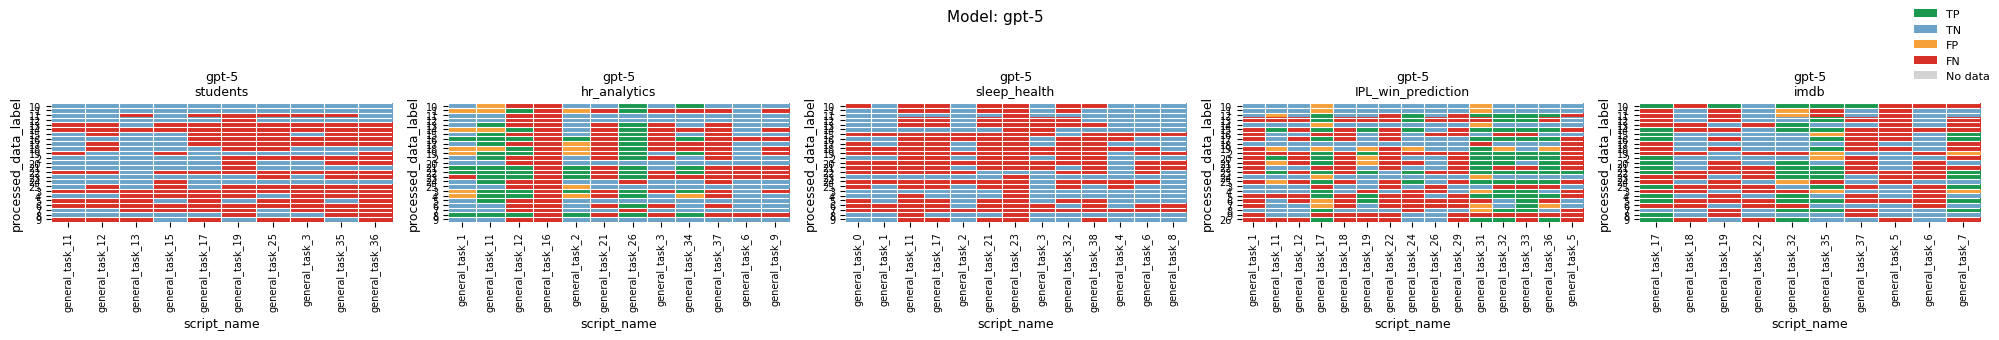

In [14]:
from workflow_prismadv.utils.results_analysis import build_correct_grids, plot_correct_grids

grids = build_correct_grids(df_all_unique, dataset_name_options, threshold=0.5)
plot_correct_grids(grids, model_order=model_order, dataset_name_options=dataset_name_options)